In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections.abc import Mapping
from pathlib import Path
import json
from plotting_utils import (
    create_df_runs,  
    PROMPT_MAPPING,
    get_nice_prompt_name,
    get_short_model_name
)


In [2]:
def flatten_run_row(row) -> list[dict]:
    run_name = row.run_name
    timestamp_str = run_name.split("__")[0]

    model_string = str(row.model)
    if model_string.lower() == "unknown":
        return []

    results = row.results
    if not isinstance(results, Mapping):
        return []

    output = []

    for case_id, case_data in results.items():
        if case_id == "run_config":
            continue

        duration = case_data.get("duration_seconds")
        if duration is None:
            continue

        output.append(
            {
                "run_name": run_name,
                "timestamp": pd.to_datetime(timestamp_str),
                "config_label": row.config_label,
                "case_id": case_id,
                "is_correct": int(case_data.get("overall_is_correct", False)),
                "duration": float(duration),
            }
        )

    return output


def flatten_runs(df_runs: pd.DataFrame) -> pd.DataFrame:
    flat_data = [
        record
        for row in df_runs.itertuples(index=False)
        for record in flatten_run_row(row)
    ]

    return pd.DataFrame(flat_data)

In [3]:
def build_case_reliability_matrix(df_target_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Takes a DataFrame of runs for a SINGLE configuration.
    Extracts the correctness of each case across all runs, and pivots it 
    into a matrix where Rows = Case IDs, and Columns = Individual Runs.
    """
    records = []
    
    # Sort by run_name (which contains the timestamp) to keep the run order logical
    df_sorted = df_target_runs.sort_values("run_name")
    
    # 1. Extract the raw pass/fail data from the results JSON
    for run_idx, (_, row) in enumerate(df_sorted.iterrows(), start=1):
        results_dict = row["results"]
        
        for case_id, case_data in results_dict.items():
            if case_id == "run_config":
                continue
                
            records.append({
                "case_id": case_id,
                "run_id": f"Run_{run_idx}",
                "is_correct": 1 if case_data.get("overall_is_correct", False) else 0
            })
            
    df_records = pd.DataFrame(records)
    
    # 2. Pivot the data so Case IDs are rows and Runs are columns
    df_matrix = df_records.pivot(index="case_id", columns="run_id", values="is_correct")
    
    # 3. Calculate the overall Pass Rate for each case
    df_matrix["Pass_Rate"] = df_matrix.mean(axis=1)
    
    # 4. Apply the exact strict categories our charts rely on
    def categorize(rate):
        if rate == 1.0:
            return "Always Passes"
        elif rate == 0.0:
            return "Systematic Fail"
        else:
            return "Flaky"
            
    df_matrix["Category"] = df_matrix["Pass_Rate"].apply(categorize)
    
    return df_matrix


def build_reliability_matrices_by_config(
    df_runs: pd.DataFrame,
    min_runs: int = 3,
) -> dict[str, pd.DataFrame]:
    """
    Build one reliability matrix per configuration, keeping only configurations
    with at least `min_runs` runs to ensure statistical relevance.
    """
    # Find which config_labels have enough runs to be evaluated
    config_counts = df_runs["config_label"].value_counts()
    eligible_config_labels = config_counts[config_counts >= min_runs].index.tolist()

    matrices = {}

    for config_label in eligible_config_labels:
        # Isolate the runs for this specific configuration
        target_runs = df_runs.loc[df_runs["config_label"] == config_label]
        
        # Build its matrix and store it in the dictionary
        matrices[config_label] = build_case_reliability_matrix(target_runs)

    return matrices

In [4]:

# 1. Load the raw data
data_dir = "../../analysis/testOutputs/child_benefit"
df_runs = create_df_runs(data_dir)

# 2. Flatten to case-level for Accuracy and Latency
df_flat = flatten_runs(df_runs)


df_runs created and its head looks like this:


,index,run_name,model,prompt,url_allowed,commit,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,1,2026-03-10T17:32:39.329093__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,55b2687,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.2_no...,Rules in prompt,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-stru...",v2.2,claude-sonnet-4-5 | Rules in prompt
1,2,2026-03-17T13:27:50.099730__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,True,d62efd3,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.md,Rules in URLs,claude-opus-4-5,"(claude-opus-4-5, Accuracy-ChildBenefit-struct...",v2,claude-opus-4-5 | Rules in URLs
2,3,2026-03-13T09:05:44.994101__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/StructuredSpecifica...,True,c099d04,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,StructuredSpecification-ChildBenefit-v1.md,Structured spec,claude-opus-4-5,"(claude-opus-4-5, StructuredSpecification-Chil...",v1,claude-opus-4-5 | Structured spec
3,4,2026-03-17T19:02:56.554521__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,78b6027,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.1_no...,Training data only,claude-opus-4-5,"(claude-opus-4-5, Accuracy-ChildBenefit-struct...",v2.1,claude-opus-4-5 | Training data only
4,5,2026-03-12T20:35:57.579893__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/StructuredSpecifica...,True,1877943,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,StructuredSpecification-ChildBenefit-v1.md,Structured spec,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v1,claude-sonnet-4-5 | Structured spec


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",6
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",5
"(claude-opus-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",5
"(claude-opus-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-sonnet-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",5
"(claude-haiku-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.1_no_links.md, False)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",5


In [5]:

# 3. Build reliability matrices to get the Strict Reliability score
reliability_matrices = build_reliability_matrices_by_config(df_runs, min_runs=3)

In [6]:
# --- A. Calculate Accuracy and Median Latency ---
df_metrics = df_flat.groupby("config_label").agg(
    accuracy=("is_correct", "mean"),
    median_latency=("duration", "median")
).reset_index()

# --- B. Calculate Strict Reliability ---
reliability_records = []
for config_label, df_matrix in reliability_matrices.items():
    # Calculate what percentage of cases fall into the "Always Passes" bucket
    category_percentages = df_matrix["Category"].value_counts(normalize=True) * 100
    always_passes = category_percentages.get("Always Passes", 0)
    
    reliability_records.append({
        "config_label": config_label,
        "strict_reliability": always_passes
    })

df_reliability = pd.DataFrame(reliability_records)

# --- C. Merge everything into df_summary ---
df_summary = pd.merge(df_metrics, df_reliability, on="config_label", how="inner")

# --- D. Extract Model and Rule Format for Plot Styling ---
# config_label format is usually: "claude-sonnet-4-5 | Rules in prompt | URLs OFF"
def extract_metadata(label):
    parts = [p.strip() for p in label.split("|")]
    model = parts[0] if len(parts) > 0 else "unknown"
    rule_format = parts[1] if len(parts) > 1 else "unknown"
    return pd.Series([model, rule_format])

df_summary[["model", "rule_format"]] = df_summary["config_label"].apply(extract_metadata)

# Convert accuracy to percentage for easier plotting
df_summary["accuracy"] *= 100

df_summary = df_summary[df_summary["rule_format"] != "Training data only"]

display(df_summary.sort_values("accuracy", ascending=False))

,config_label,accuracy,median_latency,strict_reliability,model,rule_format
5,claude-opus-4-5 | Rules in prompt,95.353535,32.16,90.909091,claude-opus-4-5,Rules in prompt
8,claude-sonnet-4-5 | Rules in prompt,93.333333,31.14,80.808081,claude-sonnet-4-5,Rules in prompt
9,claude-sonnet-4-5 | Structured spec,91.313131,80.67,81.818182,claude-sonnet-4-5,Structured spec
6,claude-opus-4-5 | Structured spec,91.111111,81.40,80.808081,claude-opus-4-5,Structured spec
4,claude-opus-4-5 | Rules in URLs,89.090909,34.43,75.757576,claude-opus-4-5,Rules in URLs
7,claude-sonnet-4-5 | Rules in URLs,88.484848,38.59,59.595960,claude-sonnet-4-5,Rules in URLs
1,claude-haiku-4-5 | Rules in prompt,88.080808,27.00,70.707071,claude-haiku-4-5,Rules in prompt
2,claude-haiku-4-5 | Structured spec,87.878788,63.90,74.747475,claude-haiku-4-5,Structured spec
0,claude-haiku-4-5 | Rules in URLs,85.050505,29.15,65.656566,claude-haiku-4-5,Rules in URLs


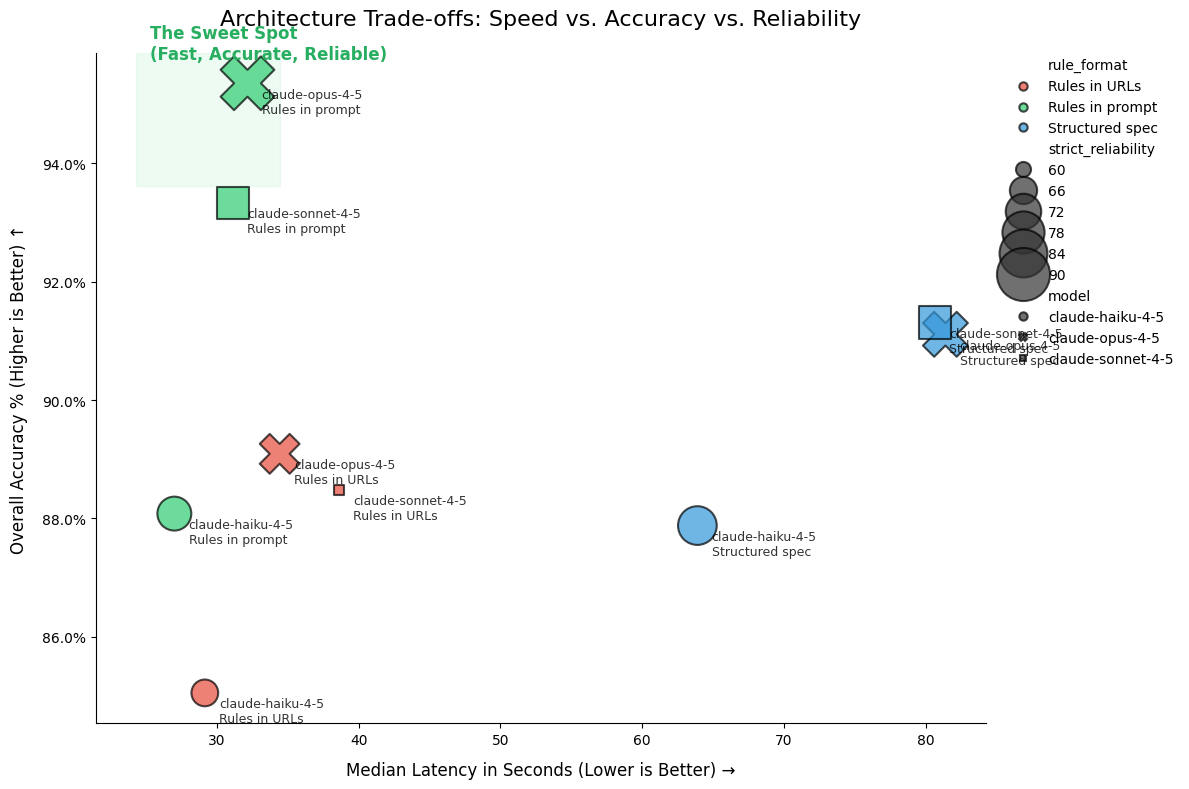

In [7]:
def plot_magic_quadrant(df_summary: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 8))

    # Optional: Customize your markers and colors to match your brand/preferences
    colors = {
        "Rules in prompt": "#2ecc71",   # Green
        "Structured spec": "#3498db",   # Blue
        "Rules in URLs": "#e74c3c"      # Red
    }
    
    # We use size="strict_reliability" to make the bubble size represent determinism
    ax = sns.scatterplot(
        data=df_summary,
        x="median_latency",
        y="accuracy",
        size="strict_reliability",
        sizes=(100, 1500),    # Min and Max bubble sizes
        hue="rule_format",
        style="model",
        palette=colors,
        alpha=0.7,            # Slight transparency to see overlapping bubbles
        edgecolor="black",
        linewidth=1.5
    )

    # --- Draw the "Sweet Spot" Highlight Box ---
    # We dynamically draw a subtle green box in the top-left quadrant
    min_lat = df_summary['median_latency'].min() * 0.9
    med_lat = df_summary['median_latency'].median()
    med_acc = df_summary['accuracy'].median()
    max_acc = df_summary['accuracy'].max() + 2 # Add a little padding to the top
    
    ax.axvspan(xmin=min_lat, xmax=med_lat, ymin=(med_acc/100)*0.9, ymax=1.0, 
               color='#2ecc71', alpha=0.08, zorder=0)
    
    plt.text(min_lat + 1, max_acc - 1, "The Sweet Spot\n(Fast, Accurate, Reliable)", 
             color="#27ae60", fontsize=12, fontweight='bold', va='top')

    # --- Formatting and Polish ---
    plt.title("Architecture Trade-offs: Speed vs. Accuracy vs. Reliability", fontsize=16, pad=20)
    plt.xlabel("Median Latency in Seconds (Lower is Better) →", fontsize=12, labelpad=10)
    plt.ylabel("Overall Accuracy % (Higher is Better) ↑", fontsize=12, labelpad=10)
    
    # Format Y-axis as percentages
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    
    # Add text labels next to each bubble so stakeholders know which dot is which
    for _, row in df_summary.iterrows():
        plt.annotate(
            row['config_label'].replace(" | ", "\n"), # Split long labels onto multiple lines
            (row['median_latency'] + 1, row['accuracy'] - 0.5), # Offset text slightly from the bubble
            fontsize=9, 
            alpha=0.8
        )

    # Clean up the legend (move it outside the plot so it doesn't cover data)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, borderaxespad=0)
    sns.despine()
    
    plt.tight_layout()
    plt.show()

# Generate the plot
plot_magic_quadrant(df_summary)

In [8]:
# This cell straight from explore_token_use.ipynb

# Pricing per token
PRICING_MATRIX_USD = {
    "haiku-4-5": {"input": 1.00 / 1e6, "output": 5.00 / 1e6},
    "sonnet-4-5": {"input": 3.00 / 1e6, "output": 15.00 / 1e6},
    "opus-4-5": {"input": 5.00 / 1e6, "output": 25.00 / 1e6},
}

GBP_TO_USD_RATE = 1.33  # £1 = $1.33
SCALE_FACTOR = 1000  # Calculate cost per 1,000 cases

def calculate_usd_cost(
    model_short_name: str, prompt_tokens: int, completion_tokens: int
):
    name_lower = model_short_name.lower()
    rates = None

    if "haiku" in name_lower:
        rates = PRICING_MATRIX_USD["haiku-4-5"]
    elif "sonnet" in name_lower:
        rates = PRICING_MATRIX_USD["sonnet-4-5"]
    elif "opus" in name_lower:
        rates = PRICING_MATRIX_USD["opus-4-5"]

    if rates:
        return (prompt_tokens * rates["input"]) + (completion_tokens * rates["output"])
    return pd.NA

def build_cost_dataframe(
    base_dir_str: str,
    prompt_mapping: dict,
    gbp_to_usd_rate: float,
    scale_factor: float,
) -> pd.DataFrame:
    """
    Scan conversation JSON files and build a dataframe of per-case token usage
    and scaled GBP cost by configuration.
    """
    cost_data = []
    base_dir = Path(base_dir_str)
    for run_dir in base_dir.iterdir():
        if not run_dir.is_dir() or run_dir.name == "eval_reports":
            continue

        for file_path in run_dir.glob("*.conversation.json"):
            try:
                with open(file_path, "r") as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                continue

            meta_block = data.get("meta", {})
            meta_content = meta_block.get("conversation", meta_block)
            run_config = meta_content.get("run_config", {})

            model_string = run_config.get("eligibility_model_string", "unknown")
            if "unknown" in model_string.lower():
                continue

            short_model_name = get_short_model_name(model_string)
            url_label = (
                "URLs ON"
                if run_config.get("url_tool_call_allowed", True)
                else "URLs OFF"
            )

            prompt_name, _ = get_nice_prompt_name(
                run_config.get("eligibility_prompt", ""),
                prompt_mapping,
            )

            config_label = f"{short_model_name} | {prompt_name}"

            plot_label = f"{short_model_name} | {prompt_mapping[prompt_name]}"

            usage = data.get("usage", {})
            prompt_tokens = usage.get("total_prompt_tokens")
            completion_tokens = usage.get("total_completion_tokens")

            if prompt_tokens is None or completion_tokens is None:
                continue

            cost_usd = calculate_usd_cost(
                short_model_name,
                prompt_tokens,
                completion_tokens,
            )

            if pd.isna(cost_usd):
                continue

            cost_gbp_scaled = (cost_usd / gbp_to_usd_rate) * scale_factor

            cost_data.append(
                {
                    "run_name": run_dir.name,
                    "case_id": data.get("case_id", file_path.stem),
                    "config_label": config_label,
                    "plot_label": plot_label,
                    "prompt_tokens": prompt_tokens,
                    "completion_tokens": completion_tokens,
                    "cost_gbp_scaled": cost_gbp_scaled,
                }
            )

    return pd.DataFrame(cost_data)

In [10]:
df_costs = build_cost_dataframe(
    "./testOutputs/child_benefit",
    PROMPT_MAPPING,
    GBP_TO_USD_RATE,
    SCALE_FACTOR,
)
df_costs

,run_name,case_id,config_label,plot_label,prompt_tokens,completion_tokens,cost_gbp_scaled
0,2026-03-10T17:32:39.329093__Model=claude-sonne...,MULTI_MIXED_THREE_MIXED,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt,42682,1280,110.711278
1,2026-03-10T17:32:39.329093__Model=claude-sonne...,RESIDENCY_FAIL_MULTI,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt,56196,1307,141.498496
2,2026-03-10T17:32:39.329093__Model=claude-sonne...,RND_047,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt,40850,892,102.203008
3,2026-03-10T17:32:39.329093__Model=claude-sonne...,RESPONSIBILITY_PASS_UPKEEP_SUFFICIENT,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt,41192,1075,105.038346
4,2026-03-10T17:32:39.329093__Model=claude-sonne...,RND_023,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt,72474,1532,180.753383
...,...,...,...,...,...,...,...
4879,2026-03-17T13:37:37.445309__Model=claude-haiku...,RND_018,claude-haiku-4-5 | Accuracy-ChildBenefit-struc...,claude-haiku-4-5 | Rules in URLs,46043,1561,40.487218
4880,2026-03-17T13:37:37.445309__Model=claude-haiku...,HOSPITAL_PASS_UNDER_12_WEEKS,claude-haiku-4-5 | Accuracy-ChildBenefit-struc...,claude-haiku-4-5 | Rules in URLs,33425,996,28.875940
4881,2026-03-17T13:37:37.445309__Model=claude-haiku...,RND_034,claude-haiku-4-5 | Accuracy-ChildBenefit-struc...,claude-haiku-4-5 | Rules in URLs,33017,1071,28.851128
4882,2026-03-17T13:37:37.445309__Model=claude-haiku...,RND_004,claude-haiku-4-5 | Accuracy-ChildBenefit-struc...,claude-haiku-4-5 | Rules in URLs,32566,1121,28.700000


In [18]:
# Calculate the median cost per 1,000 cases for each configuration
df_cost_summary = df_costs.groupby("plot_label").agg(
    median_cost_gbp=("cost_gbp_scaled", "median")
).reset_index().rename(columns={"plot_label":"config_label"})

In [19]:
df_summary["config_label"].value_counts()

config_label
claude-haiku-4-5 | Rules in URLs       1
claude-haiku-4-5 | Rules in prompt     1
claude-haiku-4-5 | Structured spec     1
claude-opus-4-5 | Rules in URLs        1
claude-opus-4-5 | Rules in prompt      1
claude-opus-4-5 | Structured spec      1
claude-sonnet-4-5 | Rules in URLs      1
claude-sonnet-4-5 | Rules in prompt    1
claude-sonnet-4-5 | Structured spec    1
Name: count, dtype: int64

In [17]:
df_cost_summary["plot_label"].value_counts()

plot_label
claude-haiku-4-5 | Rules in URLs         1
claude-haiku-4-5 | Rules in prompt       1
claude-haiku-4-5 | Structured spec       1
claude-haiku-4-5 | Training data only    1
claude-opus-4-5 | Rules in URLs          1
claude-opus-4-5 | Rules in prompt        1
claude-opus-4-5 | Structured spec        1
claude-opus-4-5 | Training data only     1
claude-sonnet-4-5 | Rules in URLs        1
claude-sonnet-4-5 | Rules in prompt      1
claude-sonnet-4-5 | Structured spec      1
Name: count, dtype: int64

In [20]:
pd.merge(df_summary, df_cost_summary, on="config_label")

,config_label,accuracy,median_latency,strict_reliability,model,rule_format,median_cost_gbp
0,claude-haiku-4-5 | Rules in URLs,85.050505,29.15,65.656566,claude-haiku-4-5,Rules in URLs,34.456391
1,claude-haiku-4-5 | Rules in prompt,88.080808,27.00,70.707071,claude-haiku-4-5,Rules in prompt,33.690226
2,claude-haiku-4-5 | Structured spec,87.878788,63.90,74.747475,claude-haiku-4-5,Structured spec,122.055639
3,claude-opus-4-5 | Rules in URLs,89.090909,34.43,75.757576,claude-opus-4-5,Rules in URLs,140.236842
4,claude-opus-4-5 | Rules in prompt,95.353535,32.16,90.909091,claude-opus-4-5,Rules in prompt,175.560150
5,claude-opus-4-5 | Structured spec,91.111111,81.40,80.808081,claude-opus-4-5,Structured spec,600.661654
6,claude-sonnet-4-5 | Rules in URLs,88.484848,38.59,59.595960,claude-sonnet-4-5,Rules in URLs,130.921805
7,claude-sonnet-4-5 | Rules in prompt,93.333333,31.14,80.808081,claude-sonnet-4-5,Rules in prompt,102.358647
8,claude-sonnet-4-5 | Structured spec,91.313131,80.67,81.818182,claude-sonnet-4-5,Structured spec,363.839098


In [21]:
# Merge it into your existing df_summary
df_summary = pd.merge(df_summary, df_cost_summary, on="config_label")

# The Magic Metric: Cases per £1
# If median_cost_gbp is the cost for 1,000 cases, then 1,000 / cost = Cases processed per £1
df_summary["cases_per_gbp"] = 1000 / df_summary["median_cost_gbp"]

In [22]:
df_summary

,config_label,accuracy,median_latency,strict_reliability,model,rule_format,median_cost_gbp,cases_per_gbp
0,claude-haiku-4-5 | Rules in URLs,85.050505,29.15,65.656566,claude-haiku-4-5,Rules in URLs,34.456391,29.022192
1,claude-haiku-4-5 | Rules in prompt,88.080808,27.00,70.707071,claude-haiku-4-5,Rules in prompt,33.690226,29.682200
2,claude-haiku-4-5 | Structured spec,87.878788,63.90,74.747475,claude-haiku-4-5,Structured spec,122.055639,8.192985
3,claude-opus-4-5 | Rules in URLs,89.090909,34.43,75.757576,claude-opus-4-5,Rules in URLs,140.236842,7.130794
4,claude-opus-4-5 | Rules in prompt,95.353535,32.16,90.909091,claude-opus-4-5,Rules in prompt,175.560150,5.696053
5,claude-opus-4-5 | Structured spec,91.111111,81.40,80.808081,claude-opus-4-5,Structured spec,600.661654,1.664831
6,claude-sonnet-4-5 | Rules in URLs,88.484848,38.59,59.595960,claude-sonnet-4-5,Rules in URLs,130.921805,7.638147
7,claude-sonnet-4-5 | Rules in prompt,93.333333,31.14,80.808081,claude-sonnet-4-5,Rules in prompt,102.358647,9.769570
8,claude-sonnet-4-5 | Structured spec,91.313131,80.67,81.818182,claude-sonnet-4-5,Structured spec,363.839098,2.748468


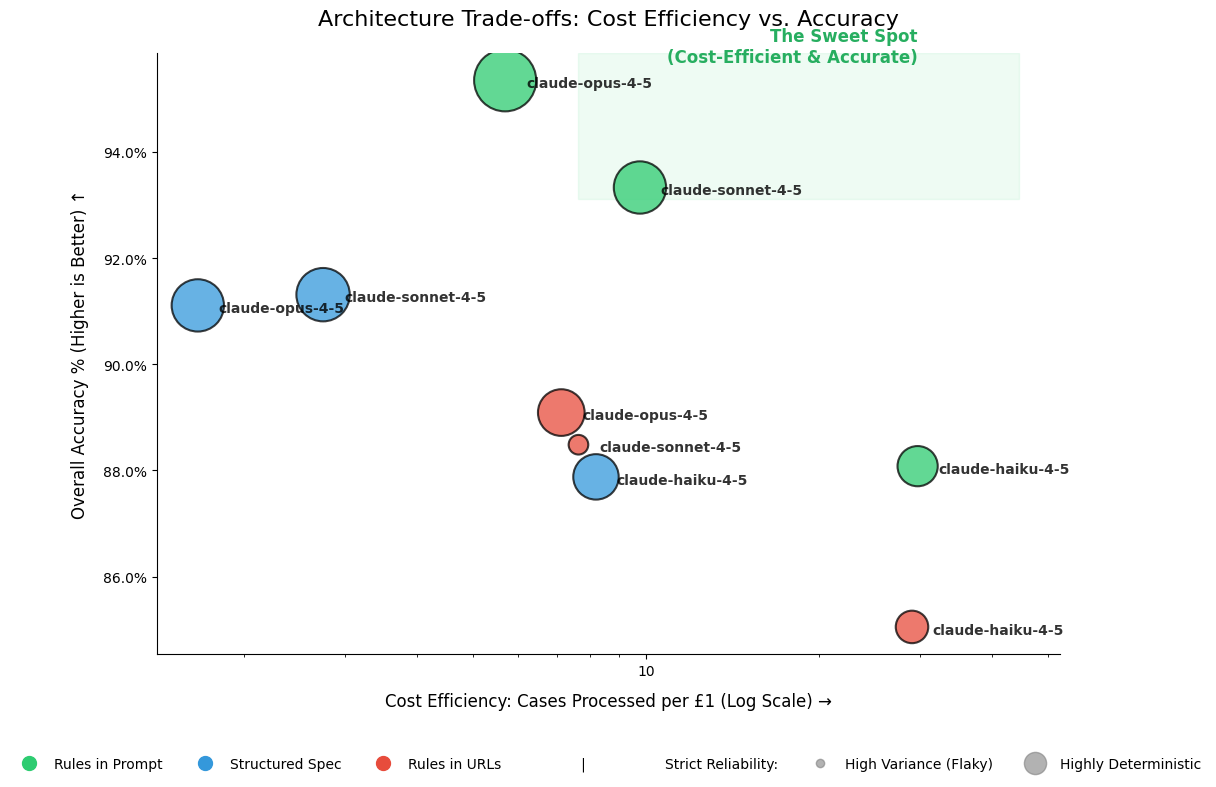

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.lines as mlines

def plot_magic_quadrant_cost(df_summary: pd.DataFrame) -> None:
    plt.figure(figsize=(12, 8))

    colors = {
        "Rules in prompt": "#2ecc71",   # Green
        "Structured spec": "#3498db",   # Blue
        "Rules in URLs": "#e74c3c"      # Red
    }
    
    # We drop 'style' so all markers are circles, making it much cleaner
    ax = sns.scatterplot(
        data=df_summary,
        x="cases_per_gbp",
        y="accuracy",
        size="strict_reliability",
        sizes=(200, 2000),    # Scaled up for better visibility
        hue="rule_format",
        palette=colors,
        alpha=0.75,
        edgecolor="black",
        linewidth=1.5,
        legend=False          # We will build a custom legend below!
    )

    # --- Draw the Top-Right "Sweet Spot" ---
    # Highlight the quadrant that is above median efficiency and median accuracy
    min_eff = df_summary['cases_per_gbp'].median()
    max_eff = df_summary['cases_per_gbp'].max() * 1.5 # Extend background slightly past max
    med_acc = df_summary['accuracy'].median()
    max_acc = df_summary['accuracy'].max() + 2 
    
    ax.axvspan(xmin=min_eff, xmax=max_eff, ymin=(med_acc/100)*0.85, ymax=1.0, 
               color='#2ecc71', alpha=0.08, zorder=0)
    
    plt.text(df_summary['cases_per_gbp'].max(), max_acc - 1, "The Sweet Spot\n(Cost-Efficient & Accurate)", 
             color="#27ae60", fontsize=12, fontweight='bold', ha='right', va='top')

    # --- Formatting ---
    plt.title("Architecture Trade-offs: Cost Efficiency vs. Accuracy", fontsize=16, pad=20)
    plt.xlabel("Cost Efficiency: Cases Processed per £1 (Log Scale) →", fontsize=12, labelpad=10)
    plt.ylabel("Overall Accuracy % (Higher is Better) ↑", fontsize=12, labelpad=10)
    
    # Log scale X-axis so Opus's cost doesn't squash Sonnet and Haiku together
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x):,}"))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    
    # Add Model Names directly to the bubbles
    for _, row in df_summary.iterrows():
        # Grab just the model name (e.g., "claude-sonnet-4-5")
        short_model = row['config_label'].split(" | ")[0]
        
        plt.annotate(
            short_model, 
            (row['cases_per_gbp'], row['accuracy']),
            xytext=(15, -5), # Offset the text slightly right and down
            textcoords='offset points',
            fontsize=10, 
            fontweight='bold',
            alpha=0.8
        )

    # --- Custom Bottom Legend ---
    legend_elements = [
        # Format Group
        mlines.Line2D([], [], color='#2ecc71', marker='o', linestyle='None', markersize=10, label='Rules in Prompt'),
        mlines.Line2D([], [], color='#3498db', marker='o', linestyle='None', markersize=10, label='Structured Spec'),
        mlines.Line2D([], [], color='#e74c3c', marker='o', linestyle='None', markersize=10, label='Rules in URLs'),
        
        # Spacer
        mlines.Line2D([], [], color='none', marker='None', label='   |   '),
        
        # Reliability Group
        mlines.Line2D([], [], color='gray', marker='None', linestyle='None', label='Strict Reliability:'),
        mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=6, alpha=0.6, label='High Variance (Flaky)'),
        mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=16, alpha=0.6, label='Highly Deterministic')
    ]
    
    plt.legend(
        handles=legend_elements, 
        bbox_to_anchor=(0.5, -0.15), # Pulls it below the X-axis
        loc='upper center', 
        ncol=7,                      # Lays it out horizontally
        frameon=False, 
        fontsize=10
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

# Generate the plot
plot_magic_quadrant_cost(df_summary)